# Autoresearch Experiment Analysis (x-transformers)

Analysis of autonomous hyperparameter tuning results from `results.tsv`.
Metric: **BPC** (bits per character) on enwik8 — lower is better.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the TSV (tab-separated, 5 columns: commit, val_bpc, memory_gb, status, description)
df = pd.read_csv("results.tsv", sep="\t")
df["val_bpc"] = pd.to_numeric(df["val_bpc"], errors="coerce")
df["memory_gb"] = pd.to_numeric(df["memory_gb"], errors="coerce")
df["status"] = df["status"].str.strip().str.upper()

print(f"Total experiments: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head(10)

Total experiments: 62
Columns: ['commit', 'val_bpc', 'memory_gb', 'status', 'description']


,commit,val_bpc,memory_gb,status,description
0,d70a8a4,1.654723,1.2,KEEP,baseline (dim=512 depth=6 heads=8 bf16 batch=4...
1,a7f30ff,1.706616,7.5,DISCARD,SwiGLU + batch=32 accum=1 lr=3e-4 (fewer token...
2,a2cfef0,1.589666,2.2,KEEP,SwiGLU + batch=8 accum=4 lr=3e-4
3,c306589,1.870771,4.4,DISCARD,dim=768 depth=8 heads=12 GQA(kv=4) SwiGLU (too...
4,895d9c5,1.765267,5.1,DISCARD,dim=640 depth=6 heads=10 batch=16 accum=2 (40M...
5,02e13f3,1.458132,2.2,KEEP,lr=5e-4 accum=2 (1618 steps 26.5M tokens)
6,e26040e,1.439029,2.1,KEEP,lr=1e-3 accum=1 (2911 steps 23.8M tokens)
7,d8bb60d,1.463104,1.2,DISCARD,batch=4 accum=1 (too noisy 4983 steps 20M tokens)
8,ccc0105,1.434387,2.2,KEEP,add_value_residual=True (ResFormer)
9,8408f62,1.422380,2.2,KEEP,shift_tokens=1 (char-level helper)


In [2]:
counts = df["status"].value_counts()
print("Experiment outcomes:")
print(counts.to_string())

n_keep = counts.get("KEEP", 0)
n_discard = counts.get("DISCARD", 0)
n_crash = counts.get("CRASH", 0)
n_decided = n_keep + n_discard
if n_decided > 0:
    print(f"\nKeep rate: {n_keep}/{n_decided} = {n_keep / n_decided:.1%}")

Experiment outcomes:
status
DISCARD    47
KEEP       13
CRASH       2

Keep rate: 13/60 = 21.7%


In [3]:
# Show all KEPT experiments (the improvements that stuck)
kept = df[df["status"] == "KEEP"].copy()
print(f"KEPT experiments ({len(kept)} total):\n")
for i, row in kept.iterrows():
    bpc = row["val_bpc"]
    desc = row["description"]
    print(f"  #{i:3d}  bpc={bpc:.6f}  mem={row['memory_gb']:.1f}GB  {desc}")

KEPT experiments (13 total):

  #  0  bpc=1.654723  mem=1.2GB  baseline (dim=512 depth=6 heads=8 bf16 batch=4 accum=4)
  #  2  bpc=1.589666  mem=2.2GB  SwiGLU + batch=8 accum=4 lr=3e-4
  #  5  bpc=1.458132  mem=2.2GB  lr=5e-4 accum=2 (1618 steps 26.5M tokens)
  #  6  bpc=1.439029  mem=2.1GB  lr=1e-3 accum=1 (2911 steps 23.8M tokens)
  #  8  bpc=1.434387  mem=2.2GB  add_value_residual=True (ResFormer)
  #  9  bpc=1.422380  mem=2.2GB  shift_tokens=1 (char-level helper)
  # 15  bpc=1.403353  mem=1.6GB  dim=384 depth=6 heads=6 (14.4M params 34.4M tokens)
  # 16  bpc=1.396422  mem=1.4GB  dim=256 depth=8 heads=4 (8.5M params 38.1M tokens)
  # 24  bpc=1.392207  mem=1.4GB  lr=1.5e-3
  # 25  bpc=1.391754  mem=1.4GB  lr=2e-3
  # 35  bpc=1.391472  mem=1.4GB  lr=2.5e-3 warmdown=40%
  # 37  bpc=1.389661  mem=1.4GB  post_emb_norm=True
  # 55  bpc=1.384562  mem=1.4GB  softclamp_output + zero_init_branch_output (Gemma2/NeoX)


## Val BPC Over Time

Track how the best (kept) val_bpc evolves as experiments progress.
The running minimum shows the "frontier" — the best result achieved so far.

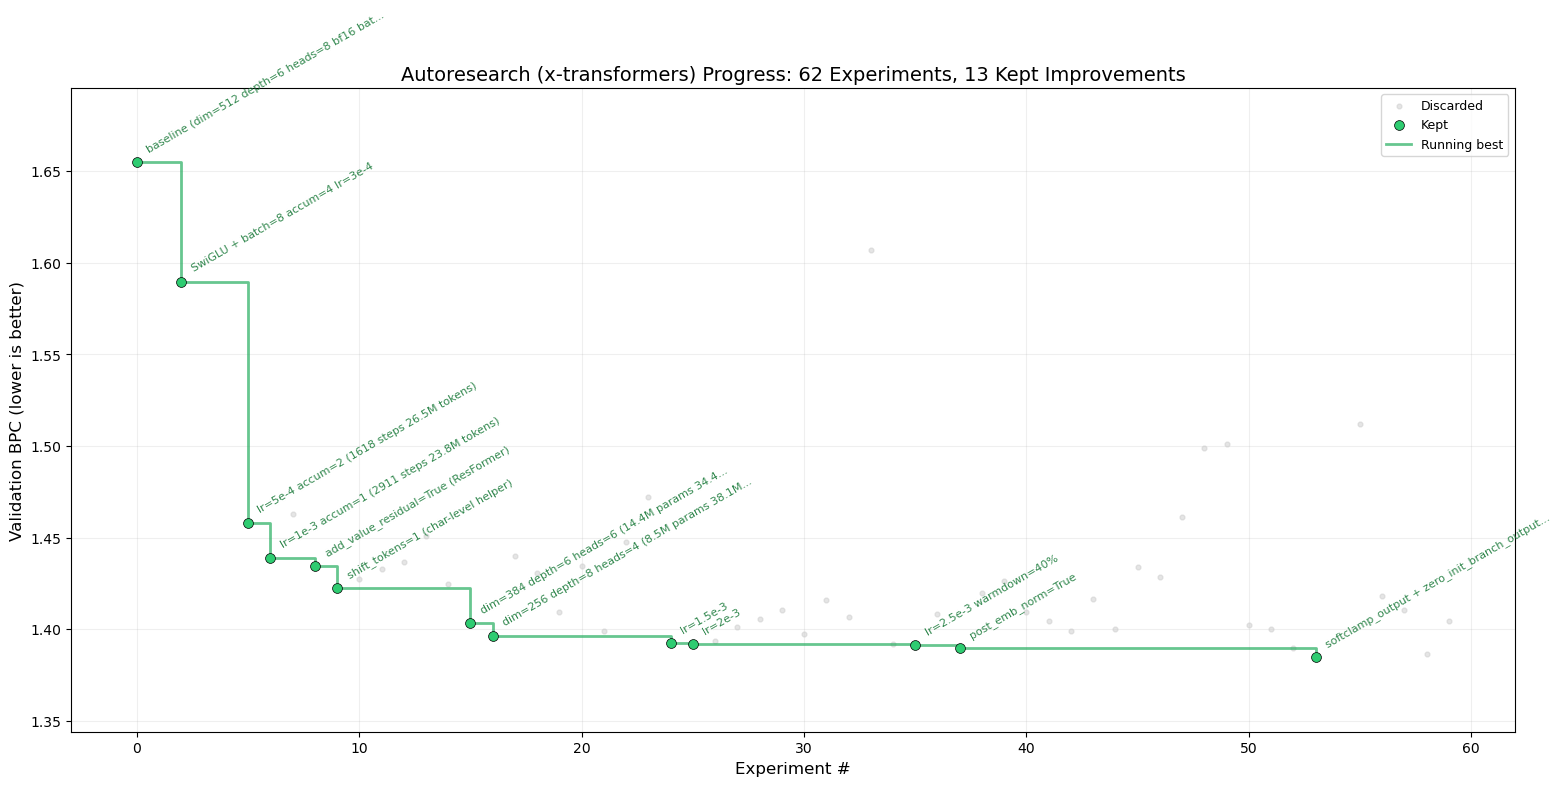

Saved to progress.png


In [4]:
fig, ax = plt.subplots(figsize=(16, 8))

# Filter out crashes for plotting
valid = df[df["status"] != "CRASH"].copy()
valid = valid.reset_index(drop=True)

baseline_bpc = valid.loc[0, "val_bpc"]

# Compute running min from kept experiments (needed for y-axis scaling)
kept_mask = valid["status"] == "KEEP"
kept_idx = valid.index[kept_mask]
kept_bpc = valid.loc[kept_mask, "val_bpc"]
running_min = kept_bpc.cummin()
best = running_min.iloc[-1] if len(running_min) > 0 else baseline_bpc

# Only plot points at or below baseline (the interesting region)
below = valid[valid["val_bpc"] <= baseline_bpc + 0.005]

# Plot discarded as faint background dots
disc = below[below["status"] == "DISCARD"]
ax.scatter(
    disc.index,
    disc["val_bpc"],
    c="#cccccc",
    s=12,
    alpha=0.5,
    zorder=2,
    label="Discarded",
)

# Plot kept experiments as prominent green dots
kept_v = below[below["status"] == "KEEP"]
ax.scatter(
    kept_v.index,
    kept_v["val_bpc"],
    c="#2ecc71",
    s=50,
    zorder=4,
    label="Kept",
    edgecolors="black",
    linewidths=0.5,
)

# Running minimum step line
ax.step(
    kept_idx,
    running_min,
    where="post",
    color="#27ae60",
    linewidth=2,
    alpha=0.7,
    zorder=3,
    label="Running best",
)

# Label each kept experiment with its description
for idx, bpc in zip(kept_idx, kept_bpc):
    desc = str(valid.loc[idx, "description"]).strip()
    if len(desc) > 45:
        desc = desc[:42] + "..."

    ax.annotate(
        desc,
        (idx, bpc),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=8.0,
        color="#1a7a3a",
        alpha=0.9,
        rotation=30,
        ha="left",
        va="bottom",
    )

n_total = len(df)
n_kept = len(df[df["status"] == "KEEP"])
ax.set_xlabel("Experiment #", fontsize=12)
ax.set_ylabel("Validation BPC (lower is better)", fontsize=12)
ax.set_title(
    f"Autoresearch (x-transformers) Progress: {n_total} Experiments, {n_kept} Kept Improvements",
    fontsize=14,
)
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.2)

# Y-axis: from just below best to just above baseline
margin = max((baseline_bpc - best) * 0.15, 0.002)
ax.set_ylim(best - margin, baseline_bpc + margin)

plt.tight_layout()
plt.savefig("progress.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to progress.png")

## Summary Statistics

In [5]:
# Summary stats
kept = df[df["status"] == "KEEP"].copy()
baseline_bpc = df.iloc[0]["val_bpc"]
best_bpc = kept["val_bpc"].min()
best_row = kept.loc[kept["val_bpc"].idxmin()]

print(f"Baseline val_bpc:  {baseline_bpc:.6f}")
print(f"Best val_bpc:      {best_bpc:.6f}")
print(
    f"Total improvement: {baseline_bpc - best_bpc:.6f} ({(baseline_bpc - best_bpc) / baseline_bpc * 100:.2f}%)"
)
print(f"Best experiment:   {best_row['description']}")
print()

# How many experiments to find each improvement
print("Cumulative effort per improvement:")
kept_sorted = kept.reset_index()
for i, (_, row) in enumerate(kept_sorted.iterrows()):
    desc = str(row["description"]).strip()
    print(f"  Experiment #{row['index']:3d}: bpc={row['val_bpc']:.6f}  {desc}")

Baseline val_bpc:  1.654723
Best val_bpc:      1.384562
Total improvement: 0.270161 (16.33%)
Best experiment:   softclamp_output + zero_init_branch_output (Gemma2/NeoX)

Cumulative effort per improvement:
  Experiment #  0: bpc=1.654723  baseline (dim=512 depth=6 heads=8 bf16 batch=4 accum=4)
  Experiment #  2: bpc=1.589666  SwiGLU + batch=8 accum=4 lr=3e-4
  Experiment #  5: bpc=1.458132  lr=5e-4 accum=2 (1618 steps 26.5M tokens)
  Experiment #  6: bpc=1.439029  lr=1e-3 accum=1 (2911 steps 23.8M tokens)
  Experiment #  8: bpc=1.434387  add_value_residual=True (ResFormer)
  Experiment #  9: bpc=1.422380  shift_tokens=1 (char-level helper)
  Experiment # 15: bpc=1.403353  dim=384 depth=6 heads=6 (14.4M params 34.4M tokens)
  Experiment # 16: bpc=1.396422  dim=256 depth=8 heads=4 (8.5M params 38.1M tokens)
  Experiment # 24: bpc=1.392207  lr=1.5e-3
  Experiment # 25: bpc=1.391754  lr=2e-3
  Experiment # 35: bpc=1.391472  lr=2.5e-3 warmdown=40%
  Experiment # 37: bpc=1.389661  post_emb_no

## Top Hits (Kept Experiments by Improvement)

In [6]:
# Each kept experiment's delta is measured vs the previous kept experiment's bpc
# (since experiments are cumulative — each one builds on the last kept state)
kept = df[df["status"] == "KEEP"].copy()
kept["prev_bpc"] = kept["val_bpc"].shift(1)
kept["delta"] = kept["prev_bpc"] - kept["val_bpc"]

# Drop baseline (no delta)
hits = kept.iloc[1:].copy()

# Sort by delta improvement (biggest first)
hits = hits.sort_values("delta", ascending=False)

print(f"{'Rank':>4}  {'Delta':>8}  {'BPC':>10}  Description")
print("-" * 80)
for rank, (_, row) in enumerate(hits.iterrows(), 1):
    print(f"{rank:4d}  {row['delta']:+.6f}  {row['val_bpc']:.6f}  {row['description']}")

print(
    f"\n{'':>4}  {hits['delta'].sum():+.6f}  {'':>10}  TOTAL improvement over baseline"
)

Rank     Delta         BPC  Description
--------------------------------------------------------------------------------
   1  +0.131534  1.458132  lr=5e-4 accum=2 (1618 steps 26.5M tokens)
   2  +0.065057  1.589666  SwiGLU + batch=8 accum=4 lr=3e-4
   3  +0.019103  1.439029  lr=1e-3 accum=1 (2911 steps 23.8M tokens)
   4  +0.019027  1.403353  dim=384 depth=6 heads=6 (14.4M params 34.4M tokens)
   5  +0.012007  1.422380  shift_tokens=1 (char-level helper)
   6  +0.006931  1.396422  dim=256 depth=8 heads=4 (8.5M params 38.1M tokens)
   7  +0.005099  1.384562  softclamp_output + zero_init_branch_output (Gemma2/NeoX)
   8  +0.004642  1.434387  add_value_residual=True (ResFormer)
   9  +0.004215  1.392207  lr=1.5e-3
  10  +0.001811  1.389661  post_emb_norm=True
  11  +0.000453  1.391754  lr=2e-3
  12  +0.000282  1.391472  lr=2.5e-3 warmdown=40%

      +0.270161              TOTAL improvement over baseline


## Memory Usage

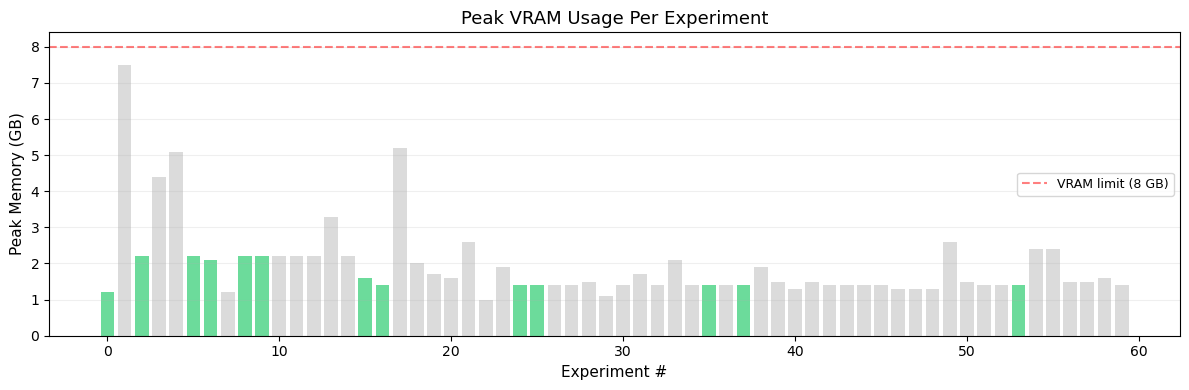

Saved to memory.png


In [7]:
fig, ax = plt.subplots(figsize=(12, 4))

valid = df[df["status"] != "CRASH"].copy().reset_index(drop=True)
colors = ["#2ecc71" if s == "KEEP" else "#cccccc" for s in valid["status"]]
ax.bar(valid.index, valid["memory_gb"], color=colors, alpha=0.7, width=0.8)
ax.axhline(y=8.0, color="red", linestyle="--", alpha=0.5, label="VRAM limit (8 GB)")
ax.set_xlabel("Experiment #", fontsize=11)
ax.set_ylabel("Peak Memory (GB)", fontsize=11)
ax.set_title("Peak VRAM Usage Per Experiment", fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2, axis="y")

plt.tight_layout()
plt.savefig("memory.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to memory.png")